In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import skimage.io as skio

# Q3: Please reduce the noise in the following image with filtering methods.

(-0.5, 511.5, 511.5, -0.5)

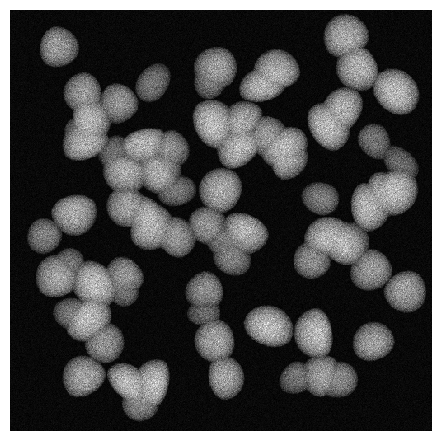

In [2]:
image = skio.imread('image_denoise.png')
skio.imshow(image)
plt.axis('off')

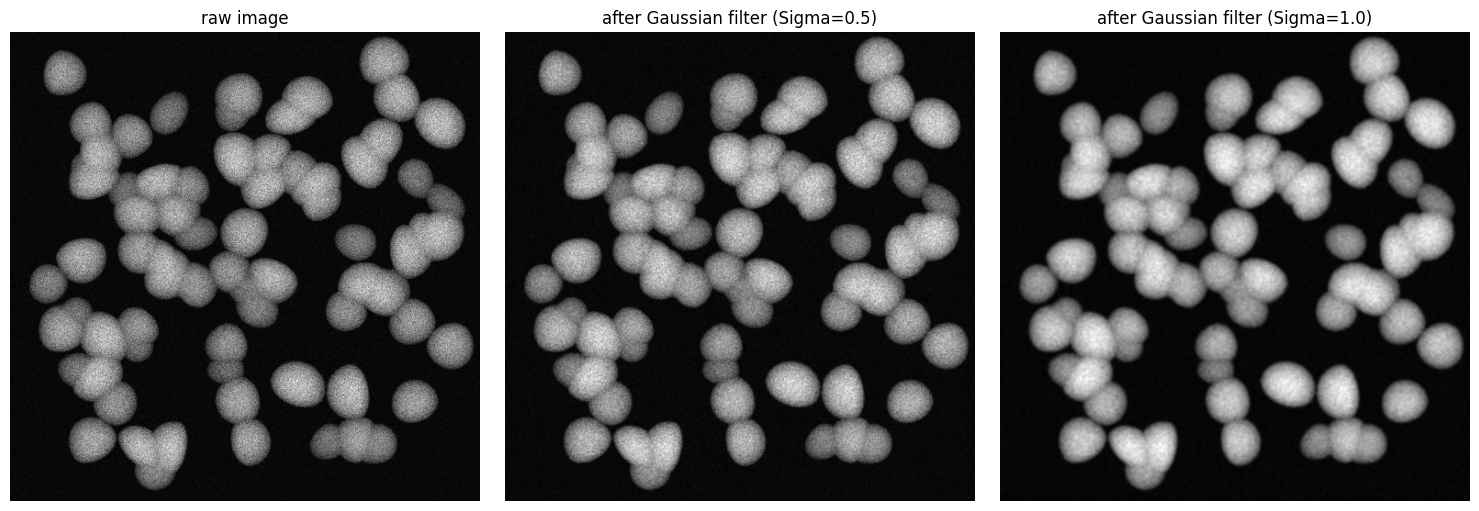

In [3]:
from skimage import filters

image_gauss1 = filters.gaussian(image, sigma=0.5)
image_gauss2 = filters.gaussian(image, sigma=1.0)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("raw image")
ax[0].axis('off')

ax[1].imshow(image_gauss1, cmap="gray")
ax[1].set_title("after Gaussian filter (Sigma=0.5)")
ax[1].axis('off')

ax[2].imshow(image_gauss2, cmap="gray")
ax[2].set_title("after Gaussian filter (Sigma=1.0)")
ax[2].axis('off')

plt.tight_layout()
plt.show()

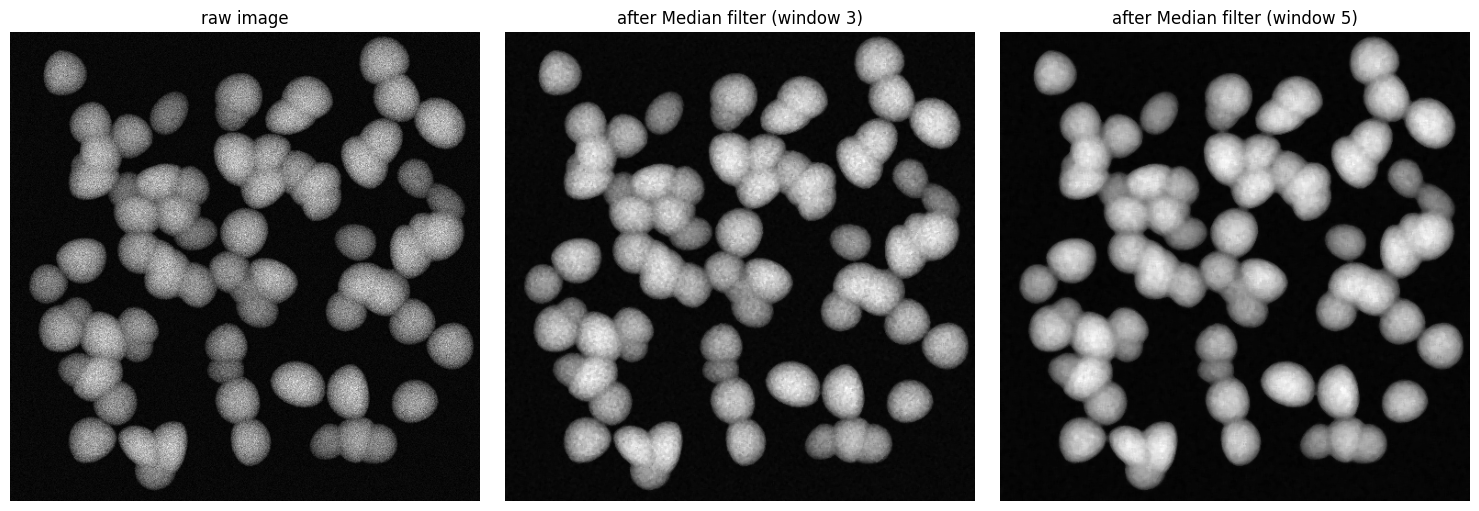

In [4]:
from skimage.morphology import rectangle

image_median1 = filters.median(image, footprint=rectangle(3, 3))
image_median2 = filters.median(image, footprint=rectangle(5, 5))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("raw image")
ax[0].axis('off')

ax[1].imshow(image_median1, cmap="gray")
ax[1].set_title("after Median filter (window 3)")
ax[1].axis('off')

ax[2].imshow(image_median2, cmap="gray")
ax[2].set_title("after Median filter (window 5)")
ax[2].axis('off')

plt.tight_layout()
plt.show()

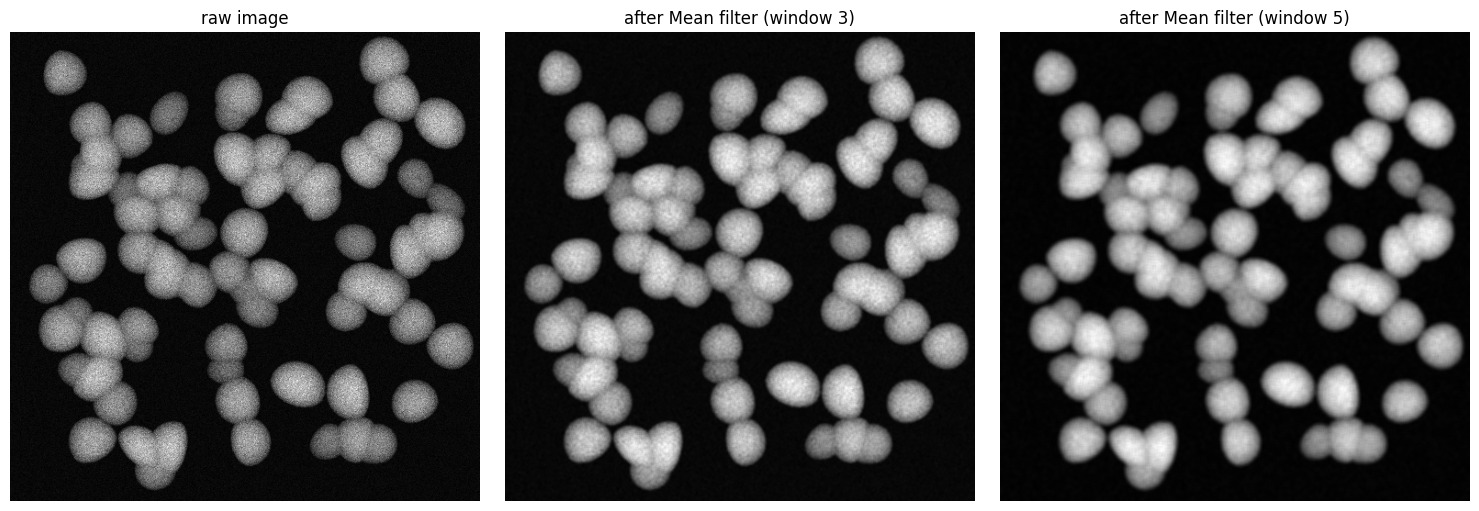

In [5]:
import skimage.filters.rank as sfr

image_mean1 = sfr.mean(image, footprint=rectangle(3, 3))
image_mean2 = sfr.mean(image, footprint=rectangle(5, 5))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("raw image")
ax[0].axis('off')

ax[1].imshow(image_mean1, cmap="gray")
ax[1].set_title("after Mean filter (window 3)")
ax[1].axis('off')

ax[2].imshow(image_mean2, cmap="gray")
ax[2].set_title("after Mean filter (window 5)")
ax[2].axis('off')

plt.tight_layout()
plt.show()

## More general: filter by 2D convolution

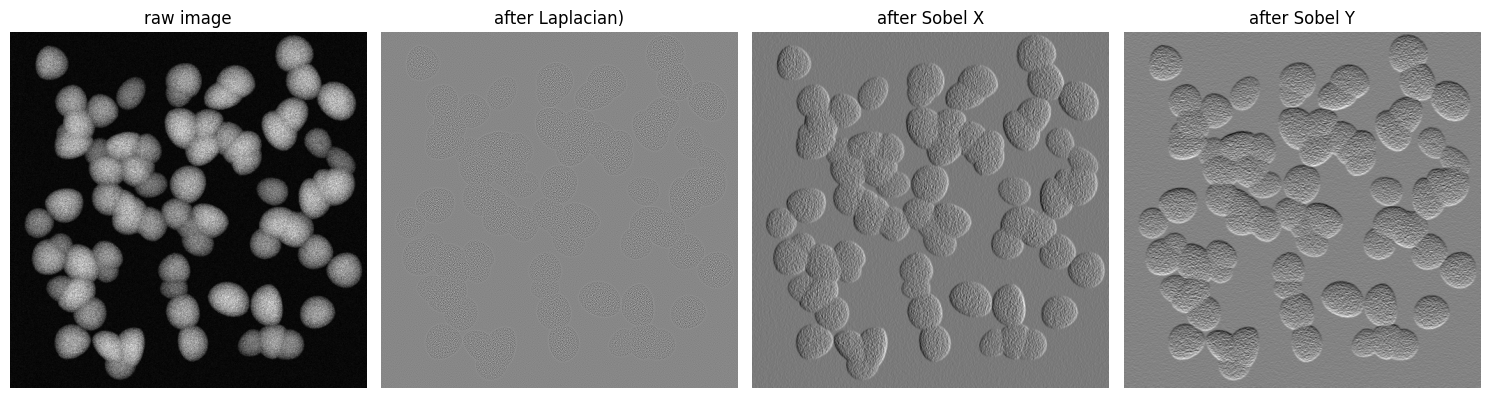

In [6]:
from scipy import signal
# Laplacian  can be used as a form of edge detection.
laplacian = np.array([[0, 1, 0],
                      [1, -4, 1],
                      [0, 1, 0]])

# the Sobel x-axis kernel
sobelX_k = np.array( [[-1, 0, 1],
                      [-2, 0, 2],
                      [-1, 0, 1]])
# the Sobel y-axis kernel
sobelY_k = np.array( [[-1, -2, -1],
                      [0, 0, 0],
                      [1, 2, 1]])

image_Lap = signal.convolve2d(np.array(image), laplacian, boundary='symm', mode="same")

image_sobelX = signal.convolve2d(np.array(image), sobelX_k, boundary='symm', mode="same")

image_sobelY = signal.convolve2d(np.array(image), sobelY_k, boundary='symm', mode="same")


fig, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("raw image")
ax[0].axis('off')

ax[1].imshow(image_Lap, cmap="gray")
ax[1].set_title("after Laplacian)")
ax[1].axis('off')

ax[2].imshow(image_sobelX, cmap="gray")
ax[2].set_title("after Sobel X")
ax[2].axis('off')

ax[3].imshow(image_sobelY, cmap="gray")
ax[3].set_title("after Sobel Y")
ax[3].axis('off')

plt.tight_layout()
plt.show()

# Q4: Please adjust the contrast of the following image with different methods and compare the results.

Range of image:  50 255
Shape of image:  (512, 512)


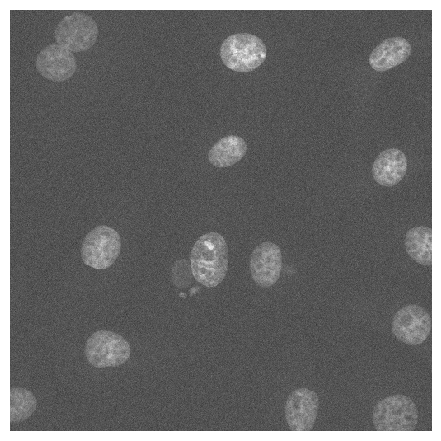

In [7]:
image = skio.imread('image_contrast.png')
skio.imshow(image)
plt.axis('off')
print('Range of image: ', np.min(image), np.max(image))
print('Shape of image: ', np.shape(image))

Range of image:  0.19607843137254902 1.0


Text(0, 0.5, 'nPixels')

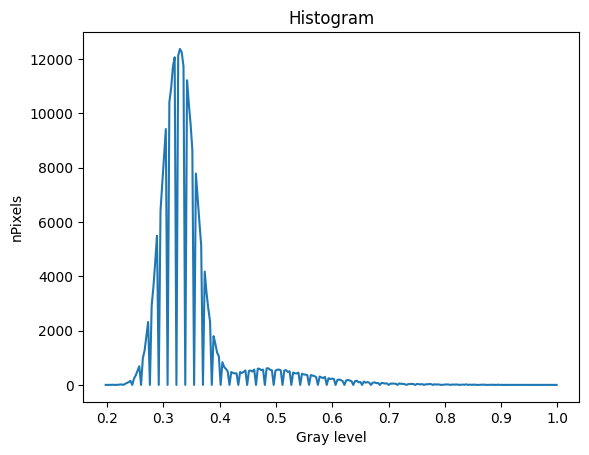

In [8]:
from skimage import exposure, img_as_float

image = img_as_float(image)

print('Range of image: ', np.min(image), np.max(image))

### histogram of raw image
histogram, bin_edges = exposure.histogram(image)
plt.plot(bin_edges, histogram)
plt.title('Histogram')
plt.xlabel('Gray level')
plt.ylabel('nPixels')

## histogram equalization

Range of image after HE:  3.814697265625e-06 1.0


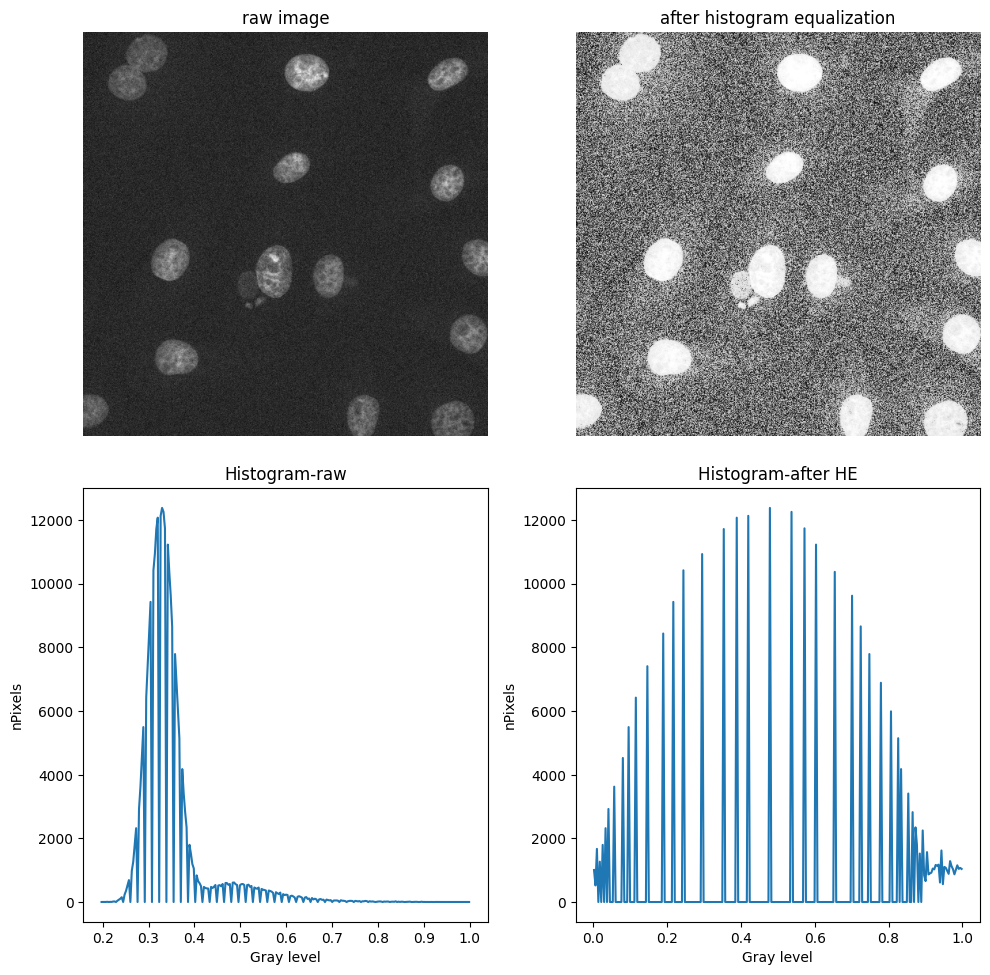

In [9]:
image_he = exposure.equalize_hist(image, mask=None)
print('Range of image after HE: ', np.min(image_he), np.max(image_he))

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].imshow(image, cmap="gray")
ax[0, 0].set_title("raw image")
ax[0, 0].axis('off')

histogram, bin_edges = exposure.histogram(image)
ax[1, 0].plot(bin_edges, histogram)
ax[1, 0].set_title('Histogram-raw')
ax[1, 0].set_xlabel('Gray level')
ax[1, 0].set_ylabel('nPixels')

ax[0, 1].imshow(image_he, cmap="gray")
ax[0, 1].set_title("after histogram equalization")
ax[0, 1].axis('off')

histogram_he, bin_edges_he = exposure.histogram(image_he)
ax[1, 1].plot(bin_edges_he, histogram_he)
ax[1, 1].set_title('Histogram-after HE')
ax[1, 1].set_xlabel('Gray level')
ax[1, 1].set_ylabel('nPixels')

plt.tight_layout()
plt.show()

## gamma correction

## $$ I_{o} = a \cdot I^\gamma $$

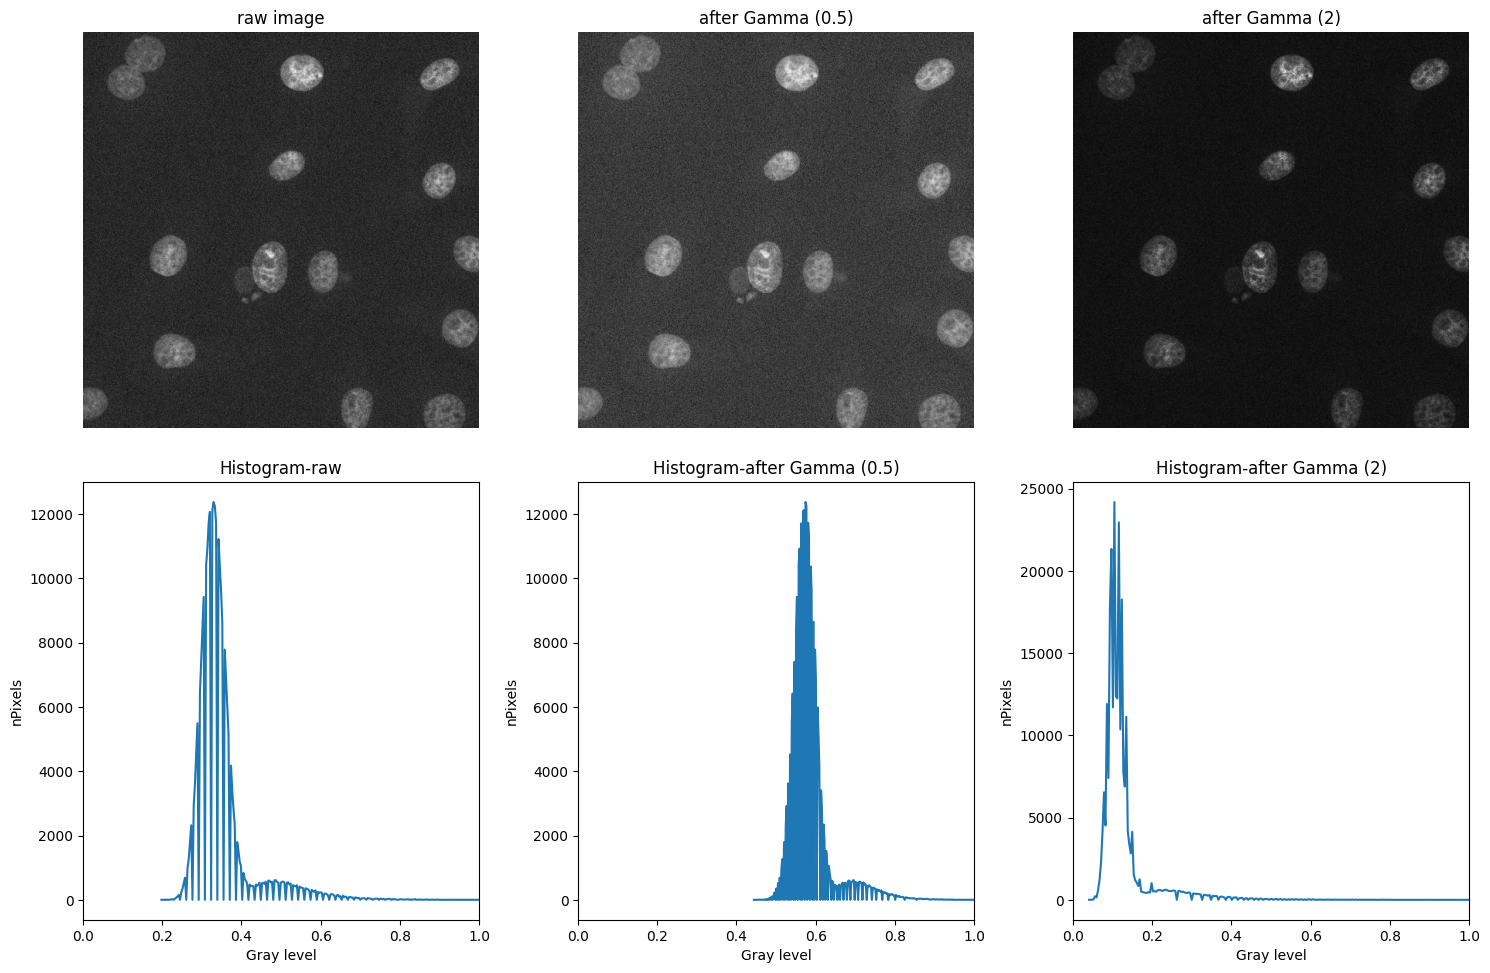

In [10]:

image_gamma1 = exposure.adjust_gamma(image, gamma=0.5, gain=1)

image_gamma2 = exposure.adjust_gamma(image, gamma=2, gain=1)

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax[0, 0].imshow(image, cmap="gray")
ax[0, 0].set_title("raw image")
ax[0, 0].axis('off')

histogram, bin_edges = exposure.histogram(image)
ax[1, 0].plot(bin_edges, histogram)
ax[1, 0].set_title('Histogram-raw')
ax[1, 0].set_xlabel('Gray level')
ax[1, 0].set_ylabel('nPixels')
ax[1, 0].set_xlim((0, 1))

ax[0, 1].imshow(image_gamma1, cmap="gray")
ax[0, 1].set_title("after Gamma (0.5)")
ax[0, 1].axis('off')

histogram_g1, bin_edges_g1 = exposure.histogram(image_gamma1)
ax[1, 1].plot(bin_edges_g1, histogram_g1)
ax[1, 1].set_title('Histogram-after Gamma (0.5)')
ax[1, 1].set_xlabel('Gray level')
ax[1, 1].set_ylabel('nPixels')
ax[1, 1].set_xlim((0, 1))

ax[0, 2].imshow(image_gamma2, cmap="gray")
ax[0, 2].set_title("after Gamma (2)")
ax[0, 2].axis('off')

histogram_g2, bin_edges_g2 = exposure.histogram(image_gamma2)
ax[1, 2].plot(bin_edges_g2, histogram_g2)
ax[1, 2].set_title('Histogram-after Gamma (2)')
ax[1, 2].set_xlabel('Gray level')
ax[1, 2].set_ylabel('nPixels')
ax[1, 2].set_xlim((0, 1))

plt.tight_layout()
plt.show()

# Q5: Please extract the foreground from the above image.

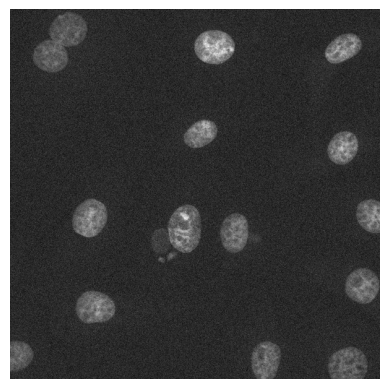

In [11]:
image = skio.imread('image_contrast.png')

plt.imshow(image, cmap='gray')
plt.axis('off')
image = img_as_float(image)

## Otsu threshold, global threshold

In [12]:
from skimage.filters import threshold_otsu

thr_otsu = threshold_otsu(image)

thr_otsu

0.4300321691176471

(-0.5, 511.5, 511.5, -0.5)

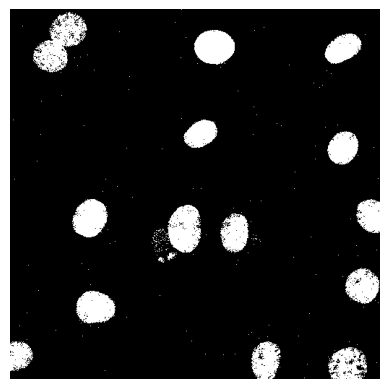

In [13]:
seg_thr_otsu = image>thr_otsu
plt.imshow(seg_thr_otsu, cmap='gray')
plt.axis('off')

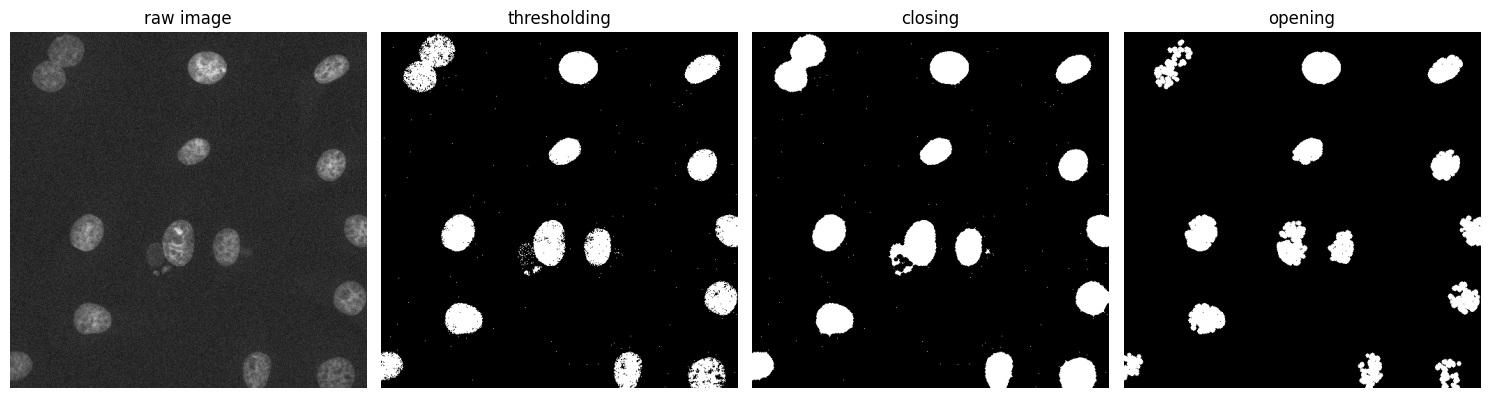

In [14]:
from skimage.morphology import binary_closing, binary_opening, disk
seg_thr_otsu_closing = binary_closing(seg_thr_otsu, footprint=disk(3))
seg_thr_otsu_opening = binary_opening(seg_thr_otsu, footprint=disk(3))

fig, ax = plt.subplots(1, 4, figsize=(15, 5))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("raw image")
ax[0].axis('off')

ax[1].imshow(seg_thr_otsu, cmap="gray")
ax[1].set_title("thresholding")
ax[1].axis('off')

ax[2].imshow(seg_thr_otsu_closing, cmap="gray")
ax[2].set_title("closing")
ax[2].axis('off')

ax[3].imshow(seg_thr_otsu_opening, cmap="gray")
ax[3].set_title("opening")
ax[3].axis('off')

plt.tight_layout()
plt.show()

## local threshold (watershed)

/tmp/ipykernel_281/4069937469.py:10: FutureWarning: indices argument is deprecated and will be removed in version 0.20. To avoid this warning, please do not use the indices argument. Please see peak_local_max documentation for more details.
  coord_max = peak_local_max(distance, footprint=np.ones((11, 11)), indices=False, labels=np.array(image_pre_seg, int))


(-0.5, 511.5, 511.5, -0.5)

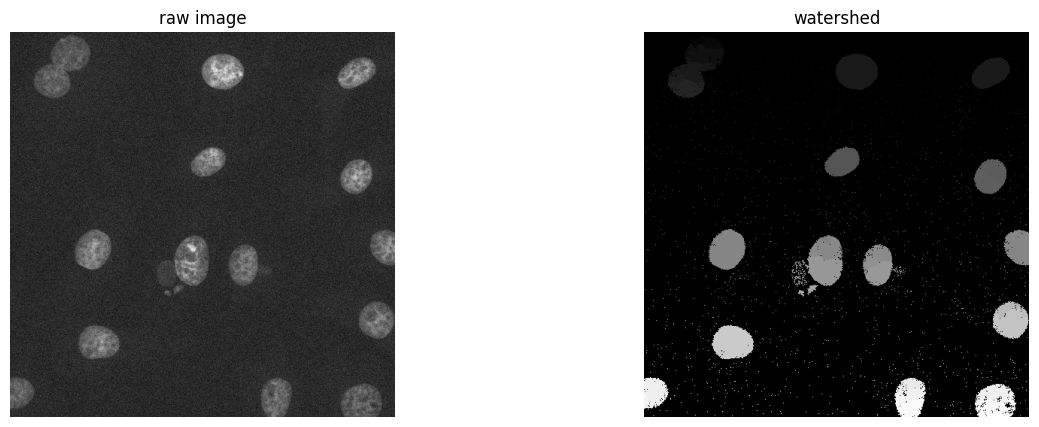

In [15]:
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage import measure

image_pre_seg = image>0.4

distance = ndi.distance_transform_edt(image_pre_seg)

coord_max = peak_local_max(distance, footprint=np.ones((11, 11)), indices=False, labels=np.array(image_pre_seg, int))
markers = measure.label(coord_max)

seg_watershed = watershed(-distance, markers=markers, mask=image_pre_seg)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("raw image")
ax[0].axis('off')

ax[1].imshow(seg_watershed, cmap="gray")
ax[1].set_title("watershed")
ax[1].axis('off')

(-0.5, 511.5, 511.5, -0.5)

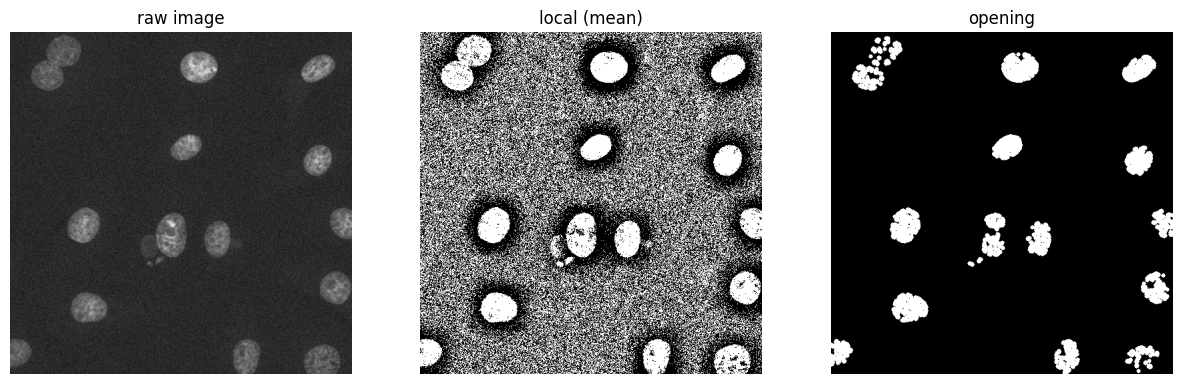

In [16]:
from skimage.filters import threshold_local

thr_local = threshold_local(image, block_size=51, method='mean')
seg_local = image>thr_local

seg_local_opening = binary_opening(seg_local, footprint=disk(3))

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(image, cmap="gray")
ax[0].set_title("raw image")
ax[0].axis('off')

ax[1].imshow(seg_local, cmap="gray")
ax[1].set_title("local (mean)")
ax[1].axis('off')

ax[2].imshow(seg_local_opening, cmap="gray")
ax[2].set_title("opening")
ax[2].axis('off')
